#### 1. Load EMNIST dataset <br>
1. Including labels
2. Results are shuffled
3. Already split into training and testing sets

In [1]:
import tensorflow_datasets as tfds
(ds_train, ds_test), ds_info = tfds.load(
    "emnist/letters",
    split=["train", "test"], # split the data
    shuffle_files=True, # shuffle the data
    as_supervised=True, # results include labels
    with_info=True, # get metadata
)
print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.6UD94R_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.6UD94R_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/letters/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Letters
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='/root/tensorflow_datasets/emnist/letters/3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=44.14 MiB,
    features=FeaturesDict({
        'image': Image

In [2]:
# Check the number of samples in training and testing sets
train_count = ds_info.splits['train'].num_examples
test_count = ds_info.splits['test'].num_examples
print(f"Number of training samples: {train_count}")
print(f"Number of testing samples: {test_count}")

Number of training samples: 88800
Number of testing samples: 14800


#### 2. Show example images from the dataset

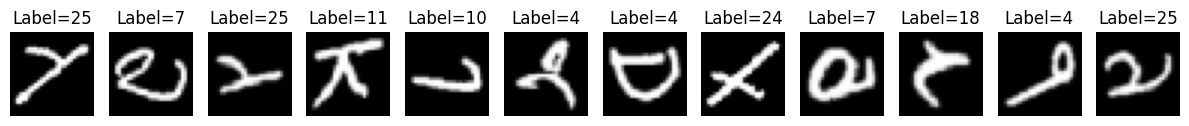

In [3]:
import matplotlib.pyplot as plt
def show_raw_samples(ds, n=12):
    for images, labels in ds.batch(n).take(1):
        images = images.numpy()
        labels = labels.numpy()

        plt.figure(figsize=(12, 3))
        for i in range(n):
            plt.subplot(1, n, i+1)
            plt.imshow(images[i].reshape(28, 28), cmap="gray")
            plt.title(f"Label={labels[i]}")
            plt.axis("off")
        plt.tight_layout()
        plt.show()

show_raw_samples(ds_train)

#### 3. Define rotation function to rotate images to the correct orientation

In [4]:
import tensorflow as tf
def fix_emnist_orientation(img):
    img = tf.image.rot90(img, k=3)
    img = tf.image.flip_left_right(img)
    return img

#### 4. Define map function, map original labels(1-26) to new labels (0-25)

In [5]:
NUM_CLASSES = 26
IMG_H, IMG_W = 28, 28

IDX2CHAR = [chr(ord('A') + i) for i in range(NUM_CLASSES)]

#### 5. Define preprocessing function to normalize, reshape, and one-hot encode labels

In [6]:
def preprocess_image(image, label):
    # normalize the image to [0, 1] range
    image = tf.cast(image, tf.float32) / 255.0
    # rotate to correct orientation, using the function defined earlier
    image = fix_emnist_orientation(image)
    # reshape image to 1D array, 28*28=784
    image = tf.reshape(image, [IMG_H * IMG_W])
    # map labels from 1-26 to 0-25
    label = tf.cast(label, tf.int32) - 1
    # one-hot encode the labels
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return image, label

#### 6. Define batch size and Pipeline for training and testing datasets

In [7]:
BATCH_SIZE = 128

train_ds = (ds_train
            .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(10000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (ds_test
           .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

#### 7. Show preprocessed example images from the dataset

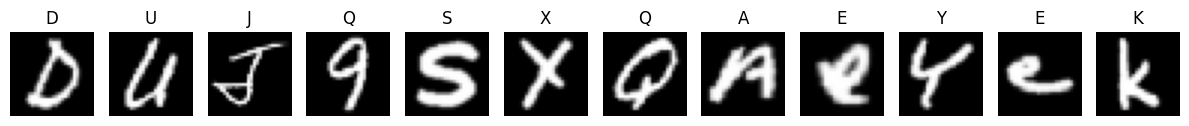

In [8]:
import numpy as np
def show_processed_samples(ds, n=12):
    for X, y in ds.take(1):
        X = X.numpy()
        y = y.numpy()

        plt.figure(figsize=(12, 3))
        for i in range(n):
            img = X[i].reshape(28, 28)
            label_idx = np.argmax(y[i])
            plt.subplot(1, n, i+1)
            plt.imshow(img, cmap="gray")
            plt.title(IDX2CHAR[label_idx])
            plt.axis("off")
        plt.tight_layout()
        plt.show()

show_processed_samples(train_ds)

#### 8. Build ANN model using Keras Sequential

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)), # input layer
    tf.keras.layers.Dense(256, activation="relu"), # hidden layer 1
    tf.keras.layers.Dropout(0.3), # dropout layer
    tf.keras.layers.Dense(128, activation="relu"), # hidden layer 2
    tf.keras.layers.Dropout(0.3), # dropout layer
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax") # output layer
])

#### 9. Compile the model, One-Hot → categorical_crossentropy

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.5326 - loss: 1.6015 - val_accuracy: 0.8018 - val_loss: 0.6338
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.7800 - loss: 0.7120 - val_accuracy: 0.8471 - val_loss: 0.4843
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8199 - loss: 0.5783 - val_accuracy: 0.8580 - val_loss: 0.4437
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8372 - loss: 0.5128 - val_accuracy: 0.8703 - val_loss: 0.3994
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8476 - loss: 0.4759 - val_accuracy: 0.8724 - val_loss: 0.3848
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8590 - loss: 0.4390 - val_accuracy: 0.8751 - val_loss: 0.3722
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.8643 - loss: 0.4195 - val_accuracy: 0.8799 - val_loss: 0.3611
Epoch 8/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8685 - loss: 0.3997 - 

#### 10. Evaluate the model on the test dataset

In [12]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8953 - loss: 0.3186
Test Accuracy: 0.8965540528297424


#### 11. Confusion Matrix, and classification report

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for X_batch, y_batch in test_ds:
    probs = model.predict(X_batch, verbose=0)
    y_pred.append(np.argmax(probs, axis=1))
    y_true.append(np.argmax(y_batch.numpy(), axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print(classification_report(y_true, y_pred, target_names=IDX2CHAR))

              precision    recall  f1-score   support

           A       0.89      0.89      0.89       800
           B       0.94      0.93      0.94       800
           C       0.94      0.94      0.94       800
           D       0.93      0.91      0.92       800
           E       0.93      0.95      0.94       800
           F       0.98      0.92      0.95       800
           G       0.86      0.75      0.80       800
           H       0.93      0.91      0.92       800
           I       0.76      0.71      0.73       800
           J       0.96      0.92      0.94       800
           K       0.97      0.93      0.95       800
           L       0.72      0.79      0.75       800
           M       0.94      0.98      0.96       800
           N       0.95      0.91      0.93       800
           O       0.92      0.97      0.94       800
           P       0.94      0.96      0.95       800
           Q       0.81      0.82      0.81       800
           R       0.95    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
